# Eddy-Current Calculation and Startup Analysis

## Overview

VEST's vessel and passive structure carry induced currents whenever the PF coils
change. Before breakdown there is nothing else in the machine, so those currents
and the coil currents together decide the field a plasma has to form in -- the
null's depth and position, the loop voltage available, and the decay index that
governs vertical stability once current flows.

This notebook solves the passive-circuit ODE for the packaged VEST shot, uses
the solution to compute the vacuum field, and reads the startup quantities off
it in time, along the midplane, and over the poloidal plane. Everything runs
from the packaged sample: no database, no external code.

## Pipeline context

Downstream of magnetic diagnostics processing
(`magnetic_diagnostics_processing.ipynb`), upstream of equilibrium
reconstruction (`magnetic_equilibrium_reconstruction_with_efit.ipynb`) and shot
classification (`shot_characteristics_classification.ipynb`). The independent
electromagnetic-response route is
`electromagnetic_response_modeling_with_efund.ipynb`.

## PF active and passive geometry inputs

The circuit model is built from what the machine description already carries:
the active coils with their turns and currents, and the passive structure as
individually resistive elements.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import vaft
from vaft.omas.process_wrapper import (
    compute_eddy_currents,
    compute_impedance_matrices_ods,
    compute_point_vacuum_fields_ods,
)
from vaft.omas.vacuum_magnetics import plasma_onset_time

SHOT = 39915
ods = vaft.omas.load(vaft.data.sample(SHOT, representation="omas"))

coils = ods["pf_active.coil"]
loops = ods["pf_passive.loop"]
time_axis = np.asarray(ods["pf_active.time"], dtype=float)
resistances = np.array([float(loops[i]["resistance"]) for i in range(len(loops))])

print(f"shot {SHOT}")
print(f"  active coils        {len(coils)}")
print(f"  passive elements    {len(loops)}")
print(f"  element resistance  {resistances.min():.3g} to {resistances.max():.3g} ohm")
print(f"  time base           {time_axis[0]:.3f} to {time_axis[-1]:.3f} s, {time_axis.size} samples")
print(f"  plasma onset        {plasma_onset_time(ods):.5f} s")

<repo>/vaft/omas/__init__.py:111: RuntimeWarning: Could not infer an IMAS DD version for omas_json; using 3.41.0


shot 39915
  active coils        10
  passive elements    950
  element resistance  0.00207 to 0.648 ohm
  time base           0.260 to 0.360 s, 2500 samples
  plasma onset        0.30628 s


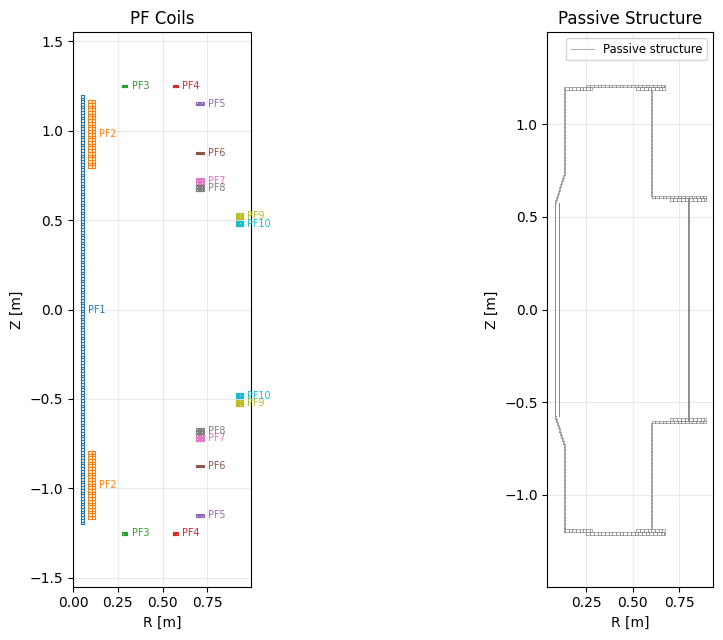

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 6.5))
vaft.omas.plot_pf_coil_geometry_poloidal(ods, label=[str(SHOT)], ax=ax[0])
vaft.omas.plot_passive_structure_geometry_poloidal(ods, label=[str(SHOT)], ax=ax[1])
fig.tight_layout()
plt.show()

## Eddy-current ODE model definition

Each passive element is one circuit. With $I_p$ the passive currents and $I_d$
the driving currents -- the active coils, plus any plasma filaments given,

$$ \mathbf{M}\,\dot{I_p} + \mathbf{R}\,I_p = -\mathbf{L}\,\dot{I_d} $$

in VAFT's naming: $\mathbf{R}$ is diagonal in the element resistances,
$\mathbf{M}$ is the passive-passive mutual inductance (its diagonal is each
element's self-inductance), and $\mathbf{L}$ is the driver-to-passive coupling.
The two inductance matrices are named the other way round from the usual circuit
convention, which is worth stating once here rather than misreading later.
`compute_impedance_matrices_ods` assembles all three from the machine
description and the `em_coupling` matrices.

In [ ]:
plasma_filaments = [(0.4, 0.0)]  # one filament, at the VEST null region
r_matrix, l_matrix, m_matrix = compute_impedance_matrices_ods(ods, plasma_filaments)

print(f"R, resistance          {r_matrix.shape}  diagonal")
print(f"M, passive-passive     {m_matrix.shape}")
print(f"L, drivers -> passive  {l_matrix.shape}"
      f"   = {len(coils)} coils + {len(plasma_filaments)} plasma filament")
print()
self_inductance = np.diag(m_matrix)
tau = self_inductance / np.diag(r_matrix)
print(f"self-inductance    {self_inductance.min():.3e} to {self_inductance.max():.3e} H")
print(f"L/R time constant  {tau.min() * 1e3:.3f} to {tau.max() * 1e3:.3f} ms"
      f"   (median {np.median(tau) * 1e3:.3f} ms)")

<repo>/vaft/omas/process_wrapper.py:436: RuntimeWarning: VEST_em_coupling_pf_versions.npz: mutual_passive_passive violates reciprocity by 0.00127 (max |M - M^T| / max |M|); symmetrized to (M + M^T)/2 on load. See issue #347.


R, resistance          (950, 950)  diagonal
M, passive-passive     (950, 950)
L, drivers -> passive  (950, 11)   = 10 coils + 1 plasma filament

self-inductance    3.470e-07 to 6.320e-06 H
L/R time constant  0.001 to 0.386 ms   (median 0.024 ms)


The longest $L/R$ of the set is what the drive has to outrun: a coil waveform
faster than it leaves current in the structure, and that current is what the
next section computes.

## Numerical integration plan

`compute_eddy_currents` integrates the system on the ODS time base, substepping
at `dt_sub` so the stiffest element is resolved, and writes the result back to
`pf_passive.loop.*.current`. The plasma filament is held at zero here: this is
the plasma-free startup phase, and giving it a current would model something
else.

In [ ]:
no_plasma_current = [np.zeros(time_axis.size)]
compute_eddy_currents(ods, plasma_filaments, no_plasma_current)

induced = np.array([
    np.asarray(loops[i]["current"], dtype=float) for i in range(len(loops))
])
total = induced.sum(axis=0)
peak_element = int(np.argmax(np.abs(induced).max(axis=1)))

print(f"induced currents   {induced.shape[0]} elements x {induced.shape[1]} samples")
print(f"total induced      {np.abs(total).max():.1f} A peak at t = {time_axis[np.argmax(np.abs(total))]:.4f} s")
print(f"largest element    #{peak_element} ({str(loops[peak_element]['name'])}), "
      f"{np.abs(induced[peak_element]).max():.1f} A")

induced currents   950 elements x 2500 samples
total induced      158368.6 A peak at t = 0.3119 s
largest element    #562 (W5), 1179.5 A


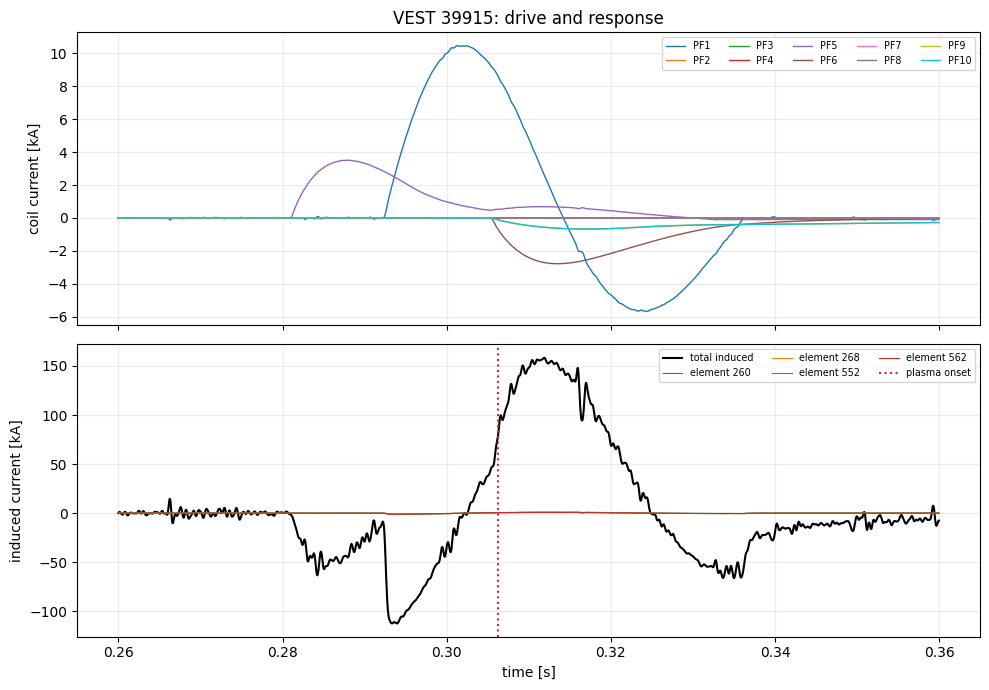

In [ ]:
fig, (ax_drive, ax_eddy) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for index in range(len(coils)):
    ax_drive.plot(time_axis, np.asarray(coils[index]["current.data"], dtype=float) / 1e3,
                  lw=1.0, label=str(coils[index]["name"]) if "name" in coils[index] else f"coil {index}")
ax_drive.set(ylabel="coil current [kA]", title=f"VEST {SHOT}: drive and response")
ax_drive.legend(fontsize="x-small", ncol=5)

ax_eddy.plot(time_axis, total / 1e3, color="black", lw=1.5, label="total induced")
for index in np.argsort(np.abs(induced).max(axis=1))[-4:]:
    ax_eddy.plot(time_axis, induced[index] / 1e3, lw=0.8,
                 label=f"element {index}")
ax_eddy.axvline(plasma_onset_time(ods), color="tab:red", ls=":", label="plasma onset")
ax_eddy.set(xlabel="time [s]", ylabel="induced current [kA]")
ax_eddy.legend(fontsize="x-small", ncol=3)
for ax in (ax_drive, ax_eddy):
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Vacuum magnetic field calculation

The field is the coils and the induced currents together. One call covers every
observation point this notebook needs -- a monitor point, a midplane line, a
poloidal grid, and the flux-loop positions -- because the cost is dominated by
the response matrix over the passive elements, not by the number of points. A
second call with `mode="pf_active"` isolates the coils, so the passive
contribution is the difference.

In [ ]:
monitor = [(0.4, 0.0)]
midplane_r = np.linspace(0.12, 0.78, 17)
midplane = [(float(r), 0.0) for r in midplane_r]
grid_r = np.linspace(0.12, 0.78, 17)
grid_z = np.linspace(-0.6, 0.6, 11)
grid = [(float(r), float(z)) for z in grid_z for r in grid_r]
flux_loops = ods["magnetics.flux_loop"]
loop_points = [
    (float(flux_loops[i]["position.0.r"]), float(flux_loops[i]["position.0.z"]))
    for i in range(len(flux_loops))
]

points = monitor + midplane + grid + loop_points
spans = {}
start = 0
for name, block in (("monitor", monitor), ("midplane", midplane),
                    ("grid", grid), ("flux_loops", loop_points)):
    spans[name] = slice(start, start + len(block))
    start += len(block)

time_arr, psi_all, br_all, bz_all = compute_point_vacuum_fields_ods(ods, points, mode="vacuum")
_, psi_coils, _, bz_coils = compute_point_vacuum_fields_ods(ods, points, mode="pf_active")

print(f"{len(points)} observation points, {time_arr.size} samples")
print(f"psi {psi_all.shape}, Br {br_all.shape}, Bz {bz_all.shape}")

216 observation points, 2500 samples
psi (2500, 216), Br (2500, 216), Bz (2500, 216)


### Does the vacuum model reproduce what the flux loops measured?

Before the plasma forms there is nothing in the machine but coils and induced
currents, so the computed flux at a loop's position should be the flux that loop
recorded. After onset the plasma contributes and the two must part company --
which is what makes the pre-onset agreement worth checking.

Flux Loop - #3         plasma-free RMS residual   0.409 mWb   (signal 27.1 mWb)
Flux Loop - #10        plasma-free RMS residual   0.415 mWb   (signal 29.8 mWb)
Flux Loop - #15        plasma-free RMS residual   0.273 mWb   (signal 31.0 mWb)


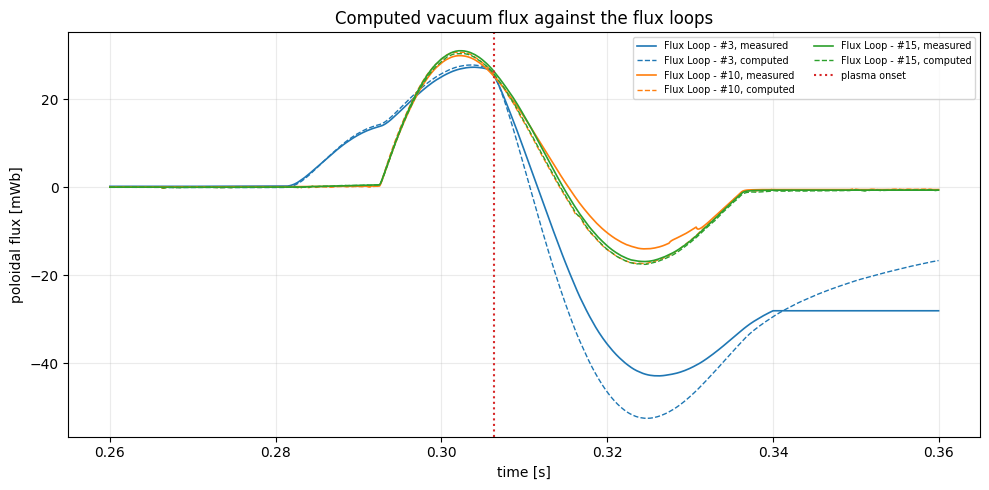

In [ ]:
onset = plasma_onset_time(ods)
before = time_arr < onset

fig, ax = plt.subplots(figsize=(10, 5))
for order, index in enumerate((0, len(loop_points) // 2, len(loop_points) - 1)):
    column = spans["flux_loops"].start + index
    measured = np.interp(
        time_arr,
        np.asarray(flux_loops[index]["flux.time"], dtype=float),
        np.asarray(flux_loops[index]["flux.data"], dtype=float),
    )
    color = f"C{order}"
    name = str(flux_loops[index]["name"])
    ax.plot(time_arr, measured * 1e3, color=color, lw=1.2, label=f"{name}, measured")
    ax.plot(time_arr, psi_all[:, column] * 1e3, color=color, lw=1.0, ls="--",
            label=f"{name}, computed")
    residual = psi_all[before, column] - measured[before]
    print(f"{name:22s} plasma-free RMS residual {np.sqrt(np.mean(residual ** 2)) * 1e3:7.3f} mWb"
          f"   (signal {np.ptp(measured[before]) * 1e3:.1f} mWb)")
ax.axvline(onset, color="tab:red", ls=":", label="plasma onset")
ax.set(xlabel="time [s]", ylabel="poloidal flux [mWb]",
       title="Computed vacuum flux against the flux loops")
ax.legend(fontsize="x-small", ncol=2)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Loop voltage and decay index

The one-turn loop voltage is the rate of change of the enclosed flux,
$V_\ell = -\,\mathrm{d}\Psi/\mathrm{d}t$, and the decay index is the local
falloff of the vertical field,

$$ n = -\frac{R}{B_z}\frac{\partial B_z}{\partial R}. $$

Both are read off the computed field rather than assumed: $0 < n < 1.5$ is the
window in which a current ring is both radially and vertically stable.

In [ ]:
def loop_voltage(psi_series, times):
    """One-turn voltage from the flux the model computed at a point."""
    return -np.gradient(psi_series, times)


def decay_index(bz_line, radii):
    """n = -(R/Bz) dBz/dR, undefined where Bz passes through zero."""
    gradient = np.gradient(bz_line, radii)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(np.abs(bz_line) > 1e-6, -radii * gradient / bz_line, np.nan)


monitor_psi = psi_all[:, spans["monitor"]][:, 0]
monitor_bz = bz_all[:, spans["monitor"]][:, 0]
monitor_voltage = loop_voltage(monitor_psi, time_arr)

print(f"at R = {monitor[0][0]} m, Z = {monitor[0][1]} m")
print(f"  peak |V_loop|  {np.abs(monitor_voltage).max():.2f} V")
print(f"  |Bz| range     {np.abs(monitor_bz).min() * 1e3:.2f} to {np.abs(monitor_bz).max() * 1e3:.2f} mT")
print(f"  at onset       V_loop = {np.interp(onset, time_arr, monitor_voltage):.2f} V, "
      f"Bz = {np.interp(onset, time_arr, monitor_bz) * 1e3:.2f} mT")

at R = 0.4 m, Z = 0.0 m
  peak |V_loop|  4.79 V
  |Bz| range     0.00 to 26.36 mT
  at onset       V_loop = 2.63 V, Bz = -0.36 mT


## Time-profile startup analysis

The startup window, at the monitor point: the flux the coils and structure
produce, the voltage that drives breakdown, and how much of the field is the
passive structure's doing rather than the coils'.

<tmp> UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


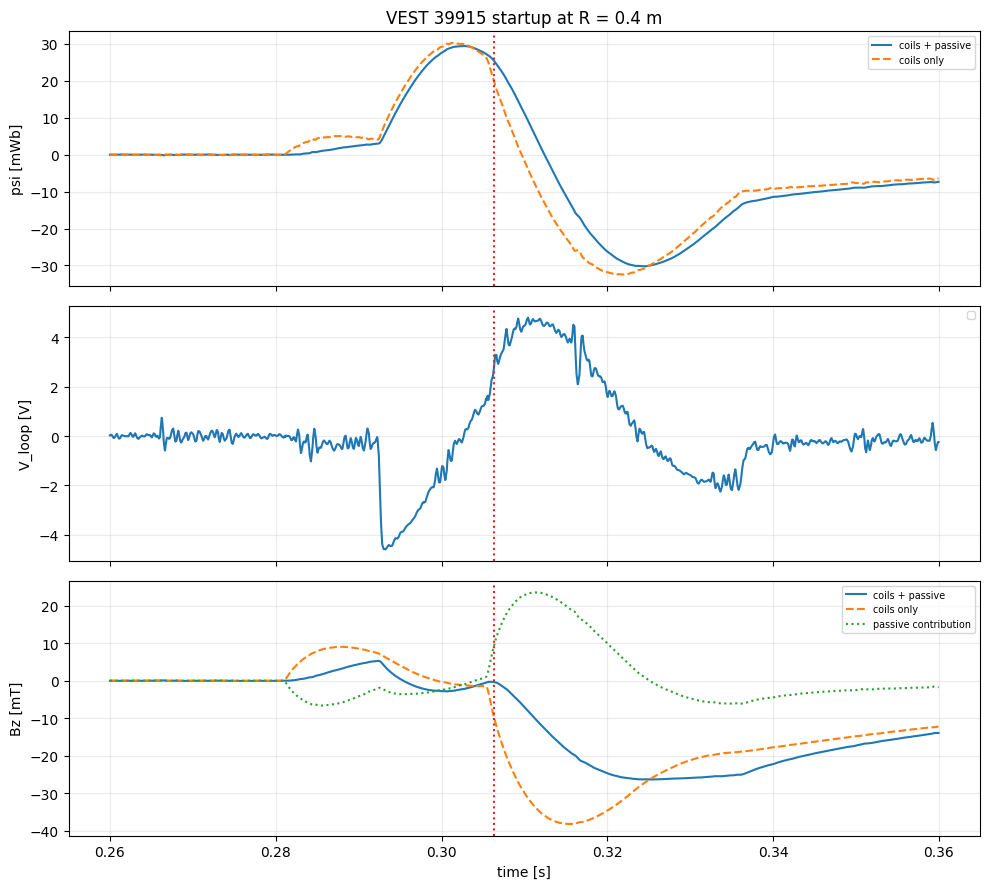

at onset:  total Bz  -0.361 mT   coils  -9.297 mT   passive  +8.936 mT
passive share of |Bz| where the field is within 10x of its peak: 21.0% (median)


In [ ]:
coil_only_bz = bz_coils[:, spans["monitor"]][:, 0]
passive_bz = monitor_bz - coil_only_bz

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
axes[0].plot(time_arr, monitor_psi * 1e3, label="coils + passive")
axes[0].plot(time_arr, psi_coils[:, spans["monitor"]][:, 0] * 1e3, ls="--", label="coils only")
axes[0].set(ylabel="psi [mWb]", title=f"VEST {SHOT} startup at R = {monitor[0][0]} m")

axes[1].plot(time_arr, monitor_voltage)
axes[1].set(ylabel="V_loop [V]")

axes[2].plot(time_arr, monitor_bz * 1e3, label="coils + passive")
axes[2].plot(time_arr, coil_only_bz * 1e3, ls="--", label="coils only")
axes[2].plot(time_arr, passive_bz * 1e3, ls=":", label="passive contribution")
axes[2].set(xlabel="time [s]", ylabel="Bz [mT]")

for ax in axes:
    ax.axvline(onset, color="tab:red", ls=":")
    ax.grid(alpha=0.25)
    ax.legend(fontsize="x-small")
fig.tight_layout()
plt.show()

# A share of |Bz| is meaningless at the monitor point, which sits near the null
# where the total passes through zero -- report the fields themselves, and the
# share only where the total field is large enough for a ratio to mean anything.
print(f"at onset:  total Bz {np.interp(onset, time_arr, monitor_bz) * 1e3:+7.3f} mT"
      f"   coils {np.interp(onset, time_arr, coil_only_bz) * 1e3:+7.3f} mT"
      f"   passive {np.interp(onset, time_arr, passive_bz) * 1e3:+7.3f} mT")
strong = np.abs(monitor_bz) > 0.1 * np.abs(monitor_bz).max()
print(f"passive share of |Bz| where the field is within 10x of its peak: "
      f"{np.median(np.abs(passive_bz[strong]) / np.abs(monitor_bz[strong])) * 100:.1f}% (median)")

## Radial-profile startup analysis

Along the midplane at the moment of breakdown: where the vertical field passes
through zero -- the null a plasma forms on -- and where the decay index sits in
its stable window.

midplane Bz sign changes at R = 0.746 m
weakest |Bz| on the scanned line: 0.025 mT at R = 0.739 m


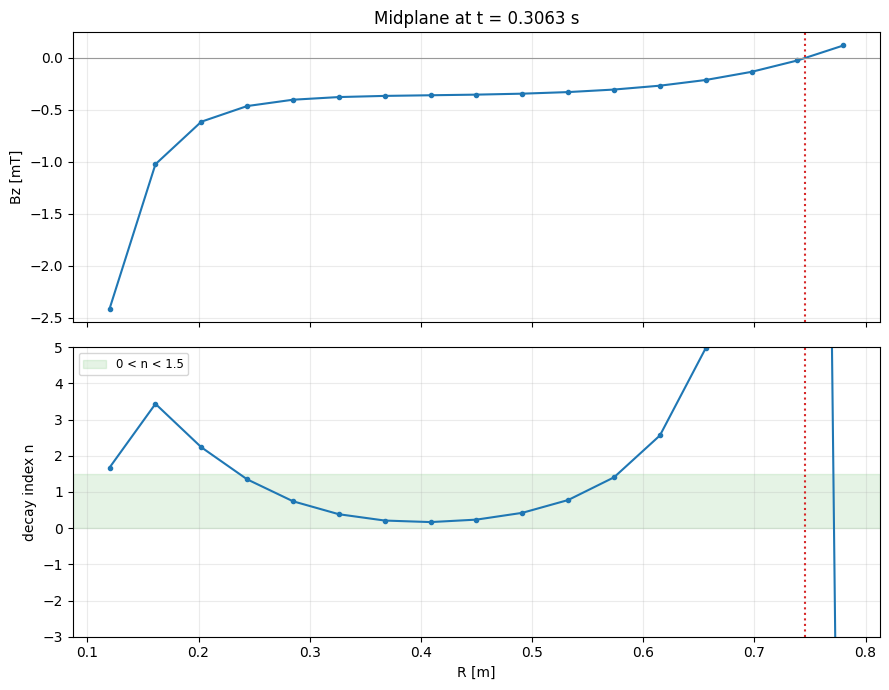

In [ ]:
at_onset = int(np.argmin(np.abs(time_arr - onset)))
bz_line = bz_all[at_onset, spans["midplane"]]
n_line = decay_index(bz_line, midplane_r)

crossings = []
for edge in np.where(np.sign(bz_line[:-1]) != np.sign(bz_line[1:]))[0]:
    left, right = midplane_r[edge], midplane_r[edge + 1]
    below, above = bz_line[edge], bz_line[edge + 1]
    crossings.append(left + (right - left) * (-below) / (above - below))

null_r = crossings[0] if crossings else None
if crossings:
    print("midplane Bz sign changes at R = "
          + ", ".join(f"{value:.3f} m" for value in crossings))
else:
    print("no midplane sign change in the scanned range")
print(f"weakest |Bz| on the scanned line: {np.abs(bz_line).min() * 1e3:.3f} mT "
      f"at R = {midplane_r[np.argmin(np.abs(bz_line))]:.3f} m")

fig, (ax_bz, ax_n) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax_bz.plot(midplane_r, bz_line * 1e3, "o-", ms=3)
ax_bz.axhline(0.0, color="0.6", lw=0.8)
ax_bz.set(ylabel="Bz [mT]", title=f"Midplane at t = {time_arr[at_onset]:.4f} s")

ax_n.plot(midplane_r, n_line, "o-", ms=3)
ax_n.axhspan(0.0, 1.5, color="tab:green", alpha=0.12, label="0 < n < 1.5")
ax_n.set(xlabel="R [m]", ylabel="decay index n", ylim=(-3, 5))
ax_n.legend(fontsize="small")
for ax in (ax_bz, ax_n):
    if null_r is not None:
        ax.axvline(null_r, color="tab:red", ls=":")
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 2D-profile startup analysis

The same instant over the poloidal plane: the flux map the coils and induced
currents produce, and the field magnitude whose minimum is the null region a
discharge starts in. The grid is deliberately coarse -- every point is another
column of the response matrix, and the whole plane is computed from the single
call above.

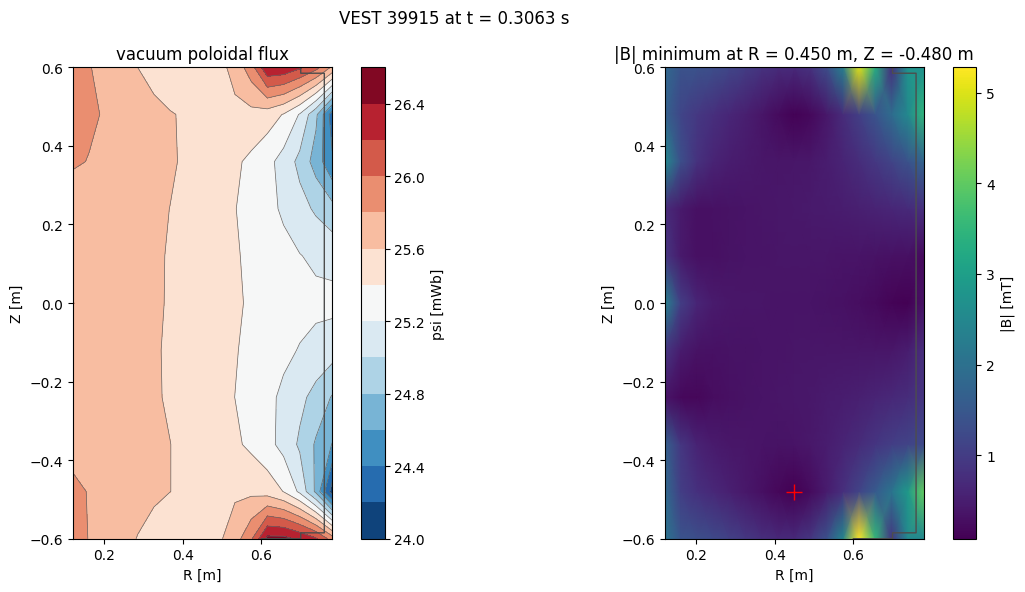

In [ ]:
shape = (grid_z.size, grid_r.size)
psi_map = psi_all[at_onset, spans["grid"]].reshape(shape)
b_map = np.hypot(br_all[at_onset, spans["grid"]], bz_all[at_onset, spans["grid"]]).reshape(shape)

fig, (ax_psi, ax_b) = plt.subplots(1, 2, figsize=(12, 6))
contour = ax_psi.contourf(grid_r, grid_z, psi_map * 1e3, levels=14, cmap="RdBu_r")
fig.colorbar(contour, ax=ax_psi, label="psi [mWb]")
ax_psi.contour(grid_r, grid_z, psi_map * 1e3, levels=14, colors="0.4", linewidths=0.5)
ax_psi.set_title("vacuum poloidal flux")

mesh = ax_b.pcolormesh(grid_r, grid_z, b_map * 1e3, shading="gouraud", cmap="viridis")
fig.colorbar(mesh, ax=ax_b, label="|B| [mT]")
minimum = np.unravel_index(np.argmin(b_map), b_map.shape)
ax_b.plot(grid_r[minimum[1]], grid_z[minimum[0]], "r+", ms=12)
ax_b.set_title(f"|B| minimum at R = {grid_r[minimum[1]]:.3f} m, Z = {grid_z[minimum[0]]:+.3f} m")

wall = ods["wall.description_2d.0.limiter.unit.0.outline"]
for ax in (ax_psi, ax_b):
    ax.plot(np.asarray(wall["r"]), np.asarray(wall["z"]), color="0.3", lw=1.0)
    ax.set(xlabel="R [m]", ylabel="Z [m]", xlim=(grid_r[0], grid_r[-1]), ylim=(grid_z[0], grid_z[-1]))
    ax.set_aspect("equal", adjustable="box")
fig.suptitle(f"VEST {SHOT} at t = {time_arr[at_onset]:.4f} s")
fig.tight_layout()
plt.show()

## Snakemake intermediate products

The eddy solve writes into the ODS it was given -- `pf_passive.loop.*.current`
is a data product, not a notebook variable -- so a pipeline rule persists it the
same way any other stage does, and the reconstruction and classification stages
read it from there.

In [ ]:
import tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as scratch:
    target = Path(scratch) / f"{SHOT}_with_eddy.json"
    vaft.omas.save(ods, target)
    reloaded = vaft.omas.load(target)
    stored = np.asarray(reloaded["pf_passive.loop"][peak_element]["current"], dtype=float)
    print(f"{target.name}: {target.stat().st_size / 1e6:.1f} MB")
    print(f"element {peak_element} current survives the round trip: "
          f"{np.allclose(stored, induced[peak_element])}")

39915_with_eddy.json: 123.1 MB
element 562 current survives the round trip: True


## What this page establishes

- The passive circuit is assembled from the machine description alone, and its
  $L/R$ spectrum says which drive rates leave current in the structure.
- The induced currents are solved on the shot's own time base and written back
  into the ODS as a data product.
- The resulting vacuum field reproduces the measured flux-loop signals in the
  plasma-free window, which is the check that makes the startup quantities
  derived from it worth reading.
- Loop voltage, decay index, the midplane null and the 2D null region all come
  from that one field calculation.

Not covered here: a plasma filament with a real current -- the filament is held
at zero throughout, because everything above is the phase before there is a
plasma to model.